In [8]:
import numpy as np
import matplotlib.pyplot as plt
from heapq import heappush, heappop

/tmp/ipykernel_1880/2731845073.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set3', 5)#5 distinct colors 0–4.


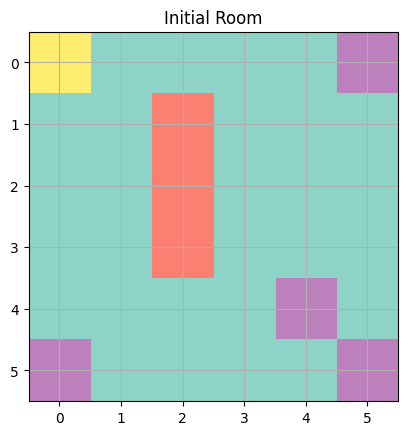

In [9]:
EMPTY = 0
OBSTACLE = 1
DIRT = 2
ROBOT = 3
CLEANED = 4


ROWS, COLS = 6, 6
grid = np.zeros((ROWS, COLS), dtype=int)
grid[1, 2] = OBSTACLE
grid[2, 2] = OBSTACLE
grid[3, 2] = OBSTACLE


grid[0, 5] = DIRT
grid[5, 0] = DIRT
grid[4, 4] = DIRT
grid[5, 5] = DIRT


start = (0, 0)
grid[start] = ROBOT

def plot_grid(grid, title="Room"):
    cmap = plt.cm.get_cmap('Set3', 5)#5 distinct colors 0–4.
    plt.imshow(grid, cmap=cmap)
    plt.grid(True)
    plt.xticks(np.arange(COLS))
    plt.yticks(np.arange(ROWS))
    plt.title(title)
    plt.show()

plot_grid(grid, "Initial Room")


for randomizing the size and positions of the elements

In [14]:
'''import random

def generate_random_grid(min_size=6, max_size=10, min_dirt=3, max_dirt=8):
    rows = random.randint(min_size, max_size)
    cols = random.randint(min_size, max_size)

    grid = np.zeros((rows, cols), dtype=int)
    all_coords = [(r, c) for r in range(rows) for c in range(cols)]
    num_obstacles = random.randint(1, 2)
    num_dirt = random.randint(min_dirt, max_dirt)

    total_items = 1 + num_obstacles + num_dirt
    selected_coords = random.sample(all_coords, total_items)

    start_pos = selected_coords[0]
    obstacle_positions = selected_coords[1 : 1 + num_obstacles]
    dirt_positions = selected_coords[1 + num_obstacles :]

    grid[start_pos] = ROBOT
    for pos in obstacle_positions:
        grid[pos] = OBSTACLE
    for pos in dirt_positions:
        grid[pos] = DIRT

    return grid, start_pos, rows, cols

grid, start, ROWS, COLS = generate_random_grid()

plot_grid(grid, f"Random Room: {ROWS}x{COLS} with {np.sum(grid == DIRT)} dirts")'''

'import random\n\ndef generate_random_grid(min_size=6, max_size=10, min_dirt=3, max_dirt=8):\n    rows = random.randint(min_size, max_size)\n    cols = random.randint(min_size, max_size)\n    \n    grid = np.zeros((rows, cols), dtype=int)\n    all_coords = [(r, c) for r in range(rows) for c in range(cols)]\n    num_obstacles = random.randint(1, 2)\n    num_dirt = random.randint(min_dirt, max_dirt)\n    \n    total_items = 1 + num_obstacles + num_dirt\n    selected_coords = random.sample(all_coords, total_items)\n    \n    start_pos = selected_coords[0]\n    obstacle_positions = selected_coords[1 : 1 + num_obstacles]\n    dirt_positions = selected_coords[1 + num_obstacles :]\n\n    grid[start_pos] = ROBOT\n    for pos in obstacle_positions:\n        grid[pos] = OBSTACLE\n    for pos in dirt_positions:\n        grid[pos] = DIRT\n        \n    return grid, start_pos, rows, cols\n\ngrid, start, ROWS, COLS = generate_random_grid()\n\nplot_grid(grid, f"Random Room: {ROWS}x{COLS} with {np.sum

In [10]:
def manhattan_dist(pos1, pos2):
    return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

def heuristic(current_pos, dirt_positions):
    if not dirt_positions:
        return 0

    nodes = [current_pos] + list(dirt_positions)
    num_nodes = len(nodes)

    #which nodes have been added to our "tree"
    in_mst = [False] * num_nodes
    in_mst[0] = True #Start building the tree from the current_pos

    min_dist = [float('inf')] * num_nodes
    for i in range(1, num_nodes):
        min_dist[i] = manhattan_dist(nodes[0], nodes[i])

    mst_cost = 0

    # Loop to add the remaining nodes to the tree
    for _ in range(num_nodes - 1):
        # Find the closest un-added node to the tree
        curr_min = float('inf')
        closest_node_idx = -1

        for i in range(1, num_nodes):
            if not in_mst[i] and min_dist[i] < curr_min:
                curr_min = min_dist[i]
                closest_node_idx = i

        if closest_node_idx == -1:
            break

        in_mst[closest_node_idx] = True
        mst_cost += curr_min
        for v in range(1, num_nodes):
            if not in_mst[v]:
                dist = manhattan_dist(nodes[closest_node_idx], nodes[v])
                if dist < min_dist[v]:
                    min_dist[v] = dist

    return mst_cost


In [ ]:
'''def heuristic(current_pos, dirt_positions):
    if not dirt_positions:
        return 0
    return min(manhattan_dist(current_pos, dirt) for dirt in dirt_positions)#get the nearest one'''

In [11]:
def get_neighbors(pos):
    moves = [(-1,0), (1,0), (0,-1), (0,1)]#4moves the robot can do
    neighbors = []
    for dx, dy in moves:
        new_x, new_y = pos[0] + dx, pos[1] + dy
        if 0 <= new_x < ROWS and 0 <= new_y < COLS and grid[new_x, new_y] != OBSTACLE:#checks if inside grid boundary(r,c),not an obstacle
            neighbors.append((new_x, new_y))
    return neighbors

def a_star(start, dirt_positions):

    open_set = []
    heappush(open_set, (heuristic(start, dirt_positions), 0, start, [start], tuple(dirt_positions)))

    visited = set()

    while open_set:
        f_cost, g_cost, current_pos, path, remaining_dirt = heappop(open_set)

        state_id = (current_pos, tuple(sorted(remaining_dirt)))
        if state_id in visited:
            continue
        visited.add(state_id)


        remaining_dirt = list(remaining_dirt)
        if current_pos in remaining_dirt:
            remaining_dirt.remove(current_pos)

        if not remaining_dirt:
            return path

        for neighbor in get_neighbors(current_pos):
            new_path = path + [neighbor]
            h_cost = heuristic(neighbor, remaining_dirt)
            heappush(open_set, (g_cost + 1 + h_cost, g_cost + 1, neighbor, new_path, tuple(remaining_dirt)))

    return None


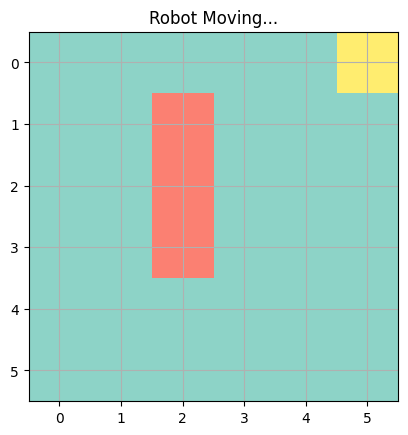

In [12]:
dirt_positions = list(zip(*np.where(grid == DIRT)))
path = a_star(start, dirt_positions)
import time
from IPython.display import clear_output

def animate_path(grid, path):
    temp_grid = np.copy(grid)
    for pos in path:
        clear_output(wait=True)
        temp_grid[temp_grid == ROBOT] = EMPTY
        if temp_grid[pos] == DIRT:
            temp_grid[pos] = CLEANED
        temp_grid[pos] = ROBOT
        plot_grid(temp_grid, title="Robot Moving...")
        time.sleep(0.5)

animate_path(grid, path)
